# INbreast EDA

## Imports

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pydicom

## Metadata File Review

The INbreast dataset provides a single CSV file with metadata for all cases:

- `datasets/INbreast Release 1.0/INbreast.csv`

The dataset includes:
- 410 mammography images from 115 cases
- Images in DICOM format
- ROI masks and XML annotations for findings
- Medical reports

In [2]:
INBREAST_ROOT = Path("../datasets/INbreast Release 1.0")

## ROI File Parsing

The ROI files are in Apple/NeXT typedstream binary format. We need to extract
the coordinate points that define the region of interest boundaries.

In [3]:
def parse_roi_file(roi_path):
    """
    Parse an INbreast ROI file and extract coordinate points.

    The ROI files are in Apple/NeXT typedstream binary format containing
    NSKeyedArchiver serialized objects with coordinate points.

    Args:
        roi_path: Path to the .roi file

    Returns:
        dict with:
            - 'points': List of (x, y) tuples representing the ROI boundary
            - 'roi_type': Type of ROI (e.g., 'Mass')
            - 'raw_data': Raw bytes for debugging
    """
    if not roi_path.exists():
        return None

    # Read the binary file
    file_bytes = roi_path.read_bytes()

    # Convert bytes to string (ignoring errors for binary data)
    file_str = file_bytes.decode('latin-1')

    # Extract coordinate points using regex
    # Points are in format {x, y}
    coord_pattern = r'\{([\d.-]+),\s*([\d.-]+)\}'
    matches = re.findall(coord_pattern, file_str)

    # Convert string coordinates to float tuples
    points = [(float(x), float(y)) for x, y in matches if not (float(x) == 0 and float(y) == 0)]

    # Try to extract ROI type (e.g., "Mass", "Calcification")
    roi_type = None
    type_patterns = ['Mass', 'Calcification', 'Cluster', 'Distortion']
    for pattern in type_patterns:
        if pattern in file_str:
            roi_type = pattern
            break

    return {
        'points': points,
        'roi_type': roi_type,
        'num_points': len(points),
        'raw_bytes': file_bytes
    }

In [4]:
def load_roi_for_image(file_name, roi_dir):
    """
    Load ROI data for a specific image file.

    Args:
        file_name: Image file name (without extension)
        roi_dir: Path to the AllROI directory

    Returns:
        Parsed ROI data or None if not found
    """
    roi_file = roi_dir / f"{file_name}.roi"
    if roi_file.exists():
        return parse_roi_file(roi_file)
    return None

In [5]:
def get_all_rois(inbreast_df, roi_dir):
    """
    Load all ROI files for images in the dataframe.

    Args:
        inbreast_df: DataFrame with INbreast metadata
        roi_dir: Path to the AllROI directory

    Returns:
        Dictionary mapping file names to ROI data
    """
    rois = {}
    for _, row in inbreast_df.iterrows():
        file_name = str(row['File Name'])
        roi_data = load_roi_for_image(file_name, roi_dir)
        if roi_data:
            rois[file_name] = roi_data
    return rois

In [6]:
inbreast_df = pd.read_csv(INBREAST_ROOT / "INbreast.csv", sep=";")
inbreast_df.head()

,Patient ID,Patient age,Laterality,View,Acquisition date,File Name,ACR,Bi-Rads
0,removed,removed,R,CC,201001,22678622,4,1
1,removed,removed,L,CC,201001,22678646,4,3
2,removed,removed,R,MLO,201001,22678670,4,1
3,removed,removed,L,MLO,201001,22678694,4,3
4,removed,removed,R,CC,201001,22614074,2,5


In [7]:
print(f"Total number of images: {len(inbreast_df)}")
print(f"Number of unique patients: {inbreast_df['Patient ID'].nunique()}")
print(f"\nDataset shape: {inbreast_df.shape}")

Total number of images: 410
Number of unique patients: 1

Dataset shape: (410, 8)


In [8]:
# Check the columns
print("Columns:")
for col in inbreast_df.columns:
    print(f"  - {col}")

Columns:
  - Patient ID
  - Patient age
  - Laterality
  - View
  - Acquisition date
  - File Name
  - ACR
  - Bi-Rads


## Image Extraction and Visualization

Let's look at how to load and display DICOM images from the INbreast dataset.

We know from the paper, that

Mammography comprehends the recording of two views for each breast:
- the craniocaudal (CC) view, which is a top to bottom view
- mediolateral oblique (MLO) view, which is a side view

I'll take a look at one example of each.

In [90]:
# Get a sample image
sample_row = inbreast_df[inbreast_df.View == "MLO"].iloc[0]
sample_filename = sample_row['File Name']
print(f"Sample image filename: {sample_filename}")

Sample image filename: 22678670


In [91]:
sample_row

Patient ID           removed
Patient age          removed
Laterality                 R
View                     MLO
Acquisition date      201001
File Name           22678670
ACR                        4
Bi-Rads                    1
pathology            Unknown
Name: 2, dtype: object

In [92]:
# Construct the DICOM file path
dicom_path = files = list((INBREAST_ROOT / "AllDICOMs").rglob(f"{sample_filename}*.dcm"))[0]
print(f"DICOM path: {dicom_path}")
print(f"File exists: {dicom_path.exists()}")

DICOM path: ../datasets/INbreast Release 1.0/AllDICOMs/22678670_61b13c59bcba149e_MG_R_ML_ANON.dcm
File exists: True


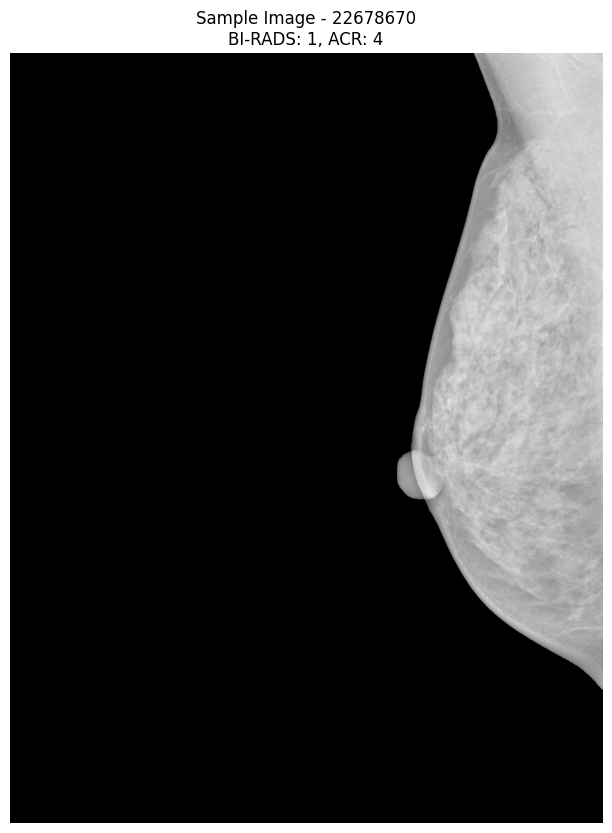

Image shape: (3328, 2560)
Pixel value range: [0, 2099]


In [93]:
# Load the DICOM file
if dicom_path.exists():
    dicom_data = pydicom.dcmread(dicom_path)
    img_array = dicom_data.pixel_array

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Sample Image - {sample_filename}\nBI-RADS: {sample_row['Bi-Rads']}, ACR: {sample_row['ACR']}")
    plt.axis('off')
    plt.show()

    print(f"Image shape: {img_array.shape}")
    print(f"Pixel value range: [{img_array.min()}, {img_array.max()}]")

In [94]:
file_name = sample_row["File Name"]
file_name

22678670

In [95]:
roi_file = INBREAST_ROOT / "AllROI" / (str(file_name) + ".roi")
print(f"ROI file: {roi_file}")
print(f"ROI file exists: {roi_file.exists()}")

ROI file: ../datasets/INbreast Release 1.0/AllROI/22678670.roi
ROI file exists: False


### Parse and visualize region-of-interest

In [96]:
# Parse the ROI file
if roi_file.exists():
    roi_data = parse_roi_file(roi_file)
    if roi_data:
        print(f"ROI Type: {roi_data['roi_type']}")
        print(f"Number of points: {roi_data['num_points']}")
        print(f"\nFirst 5 points:")
        for i, (x, y) in enumerate(roi_data['points'][:5]):
            print(f"  Point {i}: ({x:.2f}, {y:.2f})")
    else:
        print("Failed to parse ROI file")
else:
    print("ROI file not found")

ROI file not found


In [97]:
# Visualize the DICOM image with ROI overlay
if dicom_path.exists() and roi_file.exists() and roi_data:
    fig, ax = plt.subplots(figsize=(12, 12))

    # Display the mammogram
    ax.imshow(img_array, cmap='gray')

    # Overlay the ROI
    if roi_data['points']:
        roi_points = np.array(roi_data['points'])
        # Close the polygon by connecting last point to first
        roi_points = np.vstack([roi_points, roi_points[0]])

        ax.plot(roi_points[:, 0], roi_points[:, 1], 'r-', linewidth=2, label='ROI boundary')
        ax.plot(roi_points[:, 0], roi_points[:, 1], 'r.', markersize=4)

    ax.set_title(f"Image: {sample_filename} | BI-RADS: {sample_row['Bi-Rads']} | ROI Type: {roi_data['roi_type']}")
    ax.legend()
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [98]:
# Visualize with bounding box
if dicom_path.exists() and roi_file.exists() and roi_data:
    fig, ax = plt.subplots(figsize=(12, 12))

    # Display the mammogram
    ax.imshow(img_array, cmap='gray')

    # Overlay the bounding box
    if roi_data['points']:
        roi_points = np.array(roi_data['points'])

        # Calculate bounding box
        x_min, y_min = roi_points.min(axis=0)
        x_max, y_max = roi_points.max(axis=0)

        # Draw the bounding box
        from matplotlib.patches import Rectangle
        bbox = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                        linewidth=3, edgecolor='yellow', facecolor='none',
                        label='Bounding box')
        ax.add_patch(bbox)

    ax.set_title(f"Image: {sample_filename} | Bounding Box around ROI")
    ax.legend()
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [100]:
# Get a sample image
sample_row = inbreast_df[inbreast_df.View == "CC"].iloc[0]
sample_filename = sample_row['File Name']
print(f"Sample image filename: {sample_filename}")

Sample image filename: 22678622


In [101]:
# Construct the DICOM file path
dicom_path = files = list((INBREAST_ROOT / "AllDICOMs").rglob(f"{sample_filename}*.dcm"))[0]
print(f"DICOM path: {dicom_path}")
print(f"File exists: {dicom_path.exists()}")

DICOM path: ../datasets/INbreast Release 1.0/AllDICOMs/22678622_61b13c59bcba149e_MG_R_CC_ANON.dcm
File exists: True


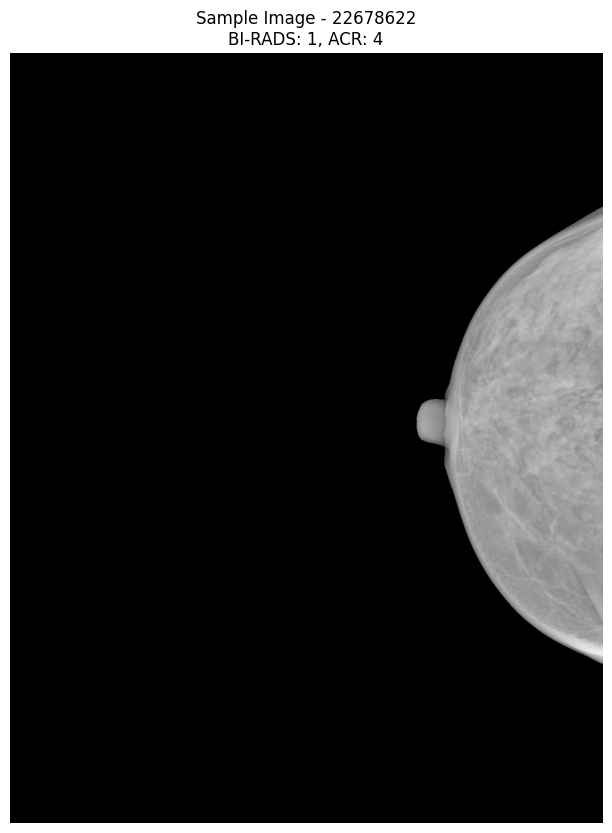

Image shape: (3328, 2560)
Pixel value range: [0, 2427]


In [102]:
# Load the DICOM file
if dicom_path.exists():
    dicom_data = pydicom.dcmread(dicom_path)
    img_array = dicom_data.pixel_array

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Sample Image - {sample_filename}\nBI-RADS: {sample_row['Bi-Rads']}, ACR: {sample_row['ACR']}")
    plt.axis('off')
    plt.show()

    print(f"Image shape: {img_array.shape}")
    print(f"Pixel value range: [{img_array.min()}, {img_array.max()}]")

## EDA

Start by analysis key characteristics of the dataset.

### BI-RADS Assessment Distribution

The BI-RADS (Breast Imaging Reporting and Data System) assessment category indicates the level of suspicion:
- 1: Negative
- 2: Benign
- 3: Probably benign
- 4a, 4b, 4c: Suspicious
- 5: Highly suggestive of malignancy
- 6: Known biopsy-proven malignancy

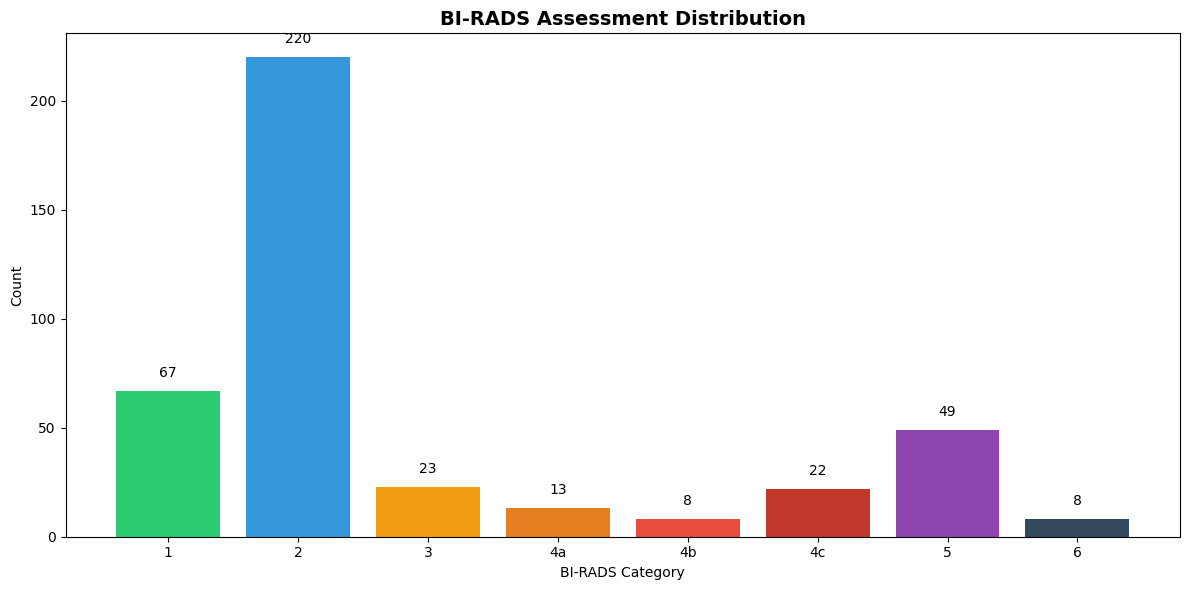

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

birads_counts = inbreast_df['Bi-Rads'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad', '#34495e']
ax.bar(birads_counts.index.astype(str), birads_counts.values, color=colors[:len(birads_counts)])
ax.set_title('BI-RADS Assessment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('BI-RADS Category')
ax.set_ylabel('Count')
for i, v in enumerate(birads_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Let's create binary labels for classification:
- Benign: BI-RADS 1, 2, 3
- Malignant: BI-RADS 4a, 4b, 4c, 5, 6

In [10]:
def classify_birads(birads):
    if birads in [1, 2, 3]:
        return 'Benign'
    elif birads in ['4a', '4b', '4c', 4, 5, 6]:
        return 'Malignant'
    else:
        return 'Unknown'

inbreast_df['pathology'] = inbreast_df['Bi-Rads'].apply(classify_birads)

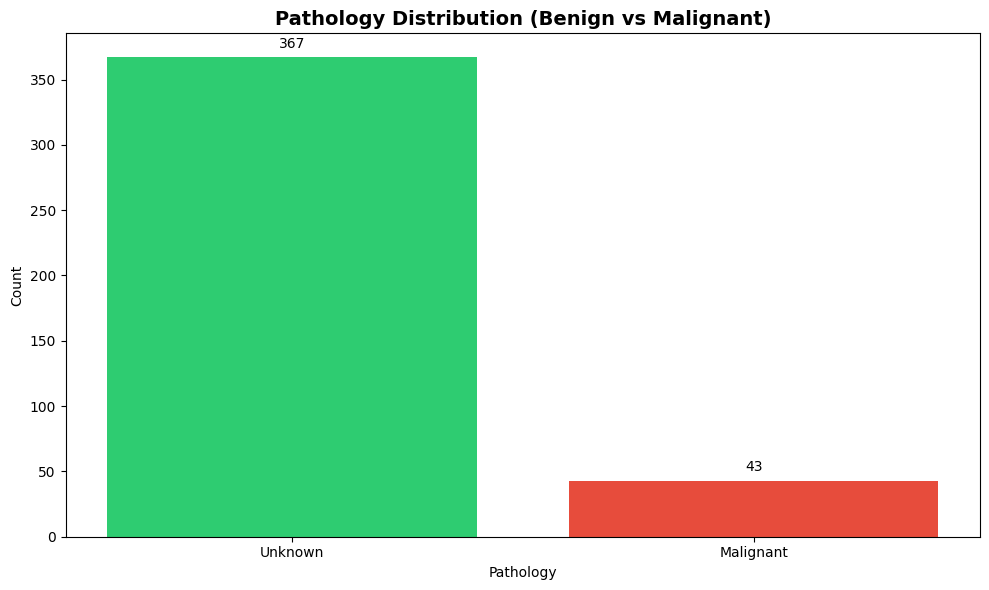

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

pathology_counts = inbreast_df['pathology'].value_counts()
colors_pathology = ['#2ecc71', '#e74c3c', '#95a5a6']
ax.bar(pathology_counts.index, pathology_counts.values, color=colors_pathology[:len(pathology_counts)])
ax.set_title('Pathology Distribution (Benign vs Malignant)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pathology')
ax.set_ylabel('Count')
for i, v in enumerate(pathology_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### ACR Breast Density Distribution

The ACR (American College of Radiology) breast density classification:
- 1: Almost entirely fatty
- 2: Scattered fibroglandular densities
- 3: Heterogeneously dense
- 4: Extremely dense

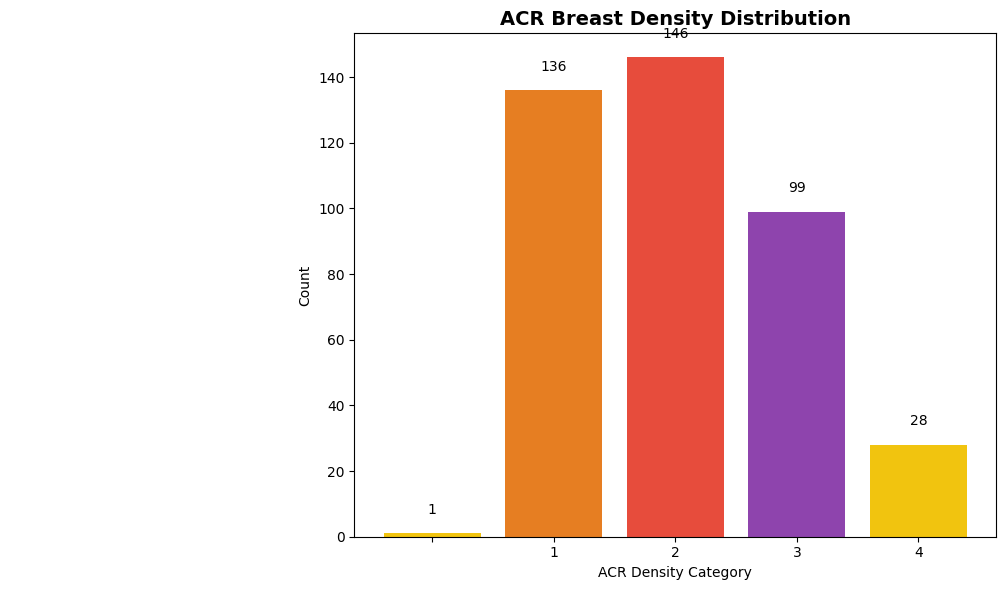

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

acr_counts = inbreast_df['ACR'].value_counts().sort_index()
# Filter out the empty string if it exists
acr_counts = acr_counts[acr_counts.index != '']
colors_acr = ['#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
ax.bar(acr_counts.index.astype(str), acr_counts.values, color=colors_acr)
ax.set_title('ACR Breast Density Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('ACR Density Category')
ax.set_ylabel('Count')
for i, v in enumerate(acr_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Image View Distribution

Standard mammography views:
- CC: Craniocaudal view
- MLO: Mediolateral oblique view

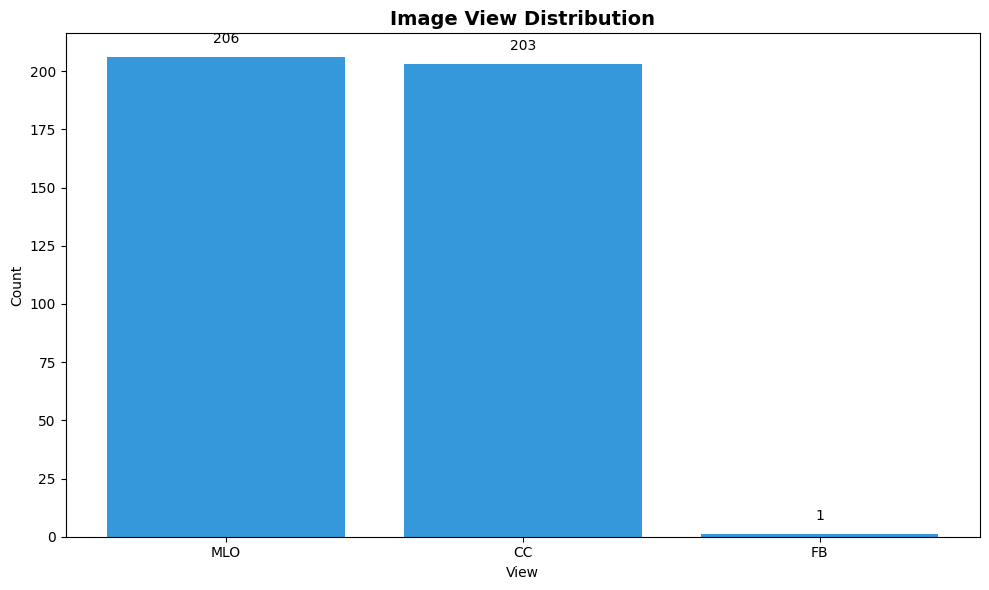

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

view_counts = inbreast_df['View'].value_counts()
ax.bar(view_counts.index, view_counts.values, color='#3498db')
ax.set_title('Image View Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('View')
ax.set_ylabel('Count')
for i, v in enumerate(view_counts.values):
    ax.text(i, v + 5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Laterality Distribution

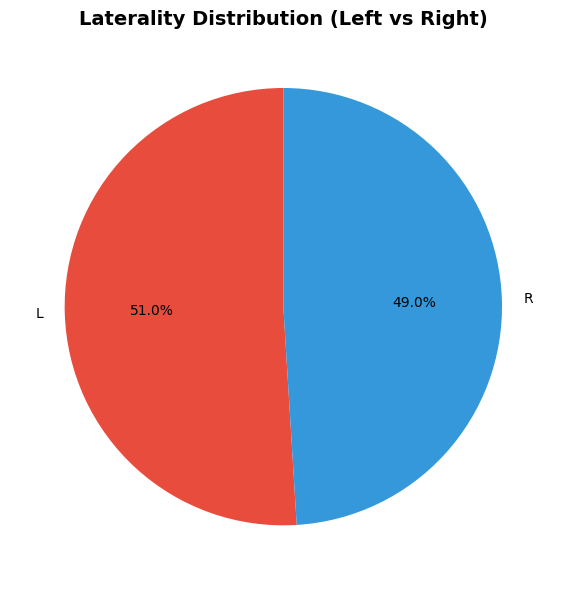

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

laterality_counts = inbreast_df['Laterality'].value_counts()
ax.pie(laterality_counts.values, labels=laterality_counts.index, autopct='%1.1f%%',
       colors=['#e74c3c', '#3498db'], startangle=90)
ax.set_title('Laterality Distribution (Left vs Right)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Cross-Analysis: BI-RADS by ACR Density

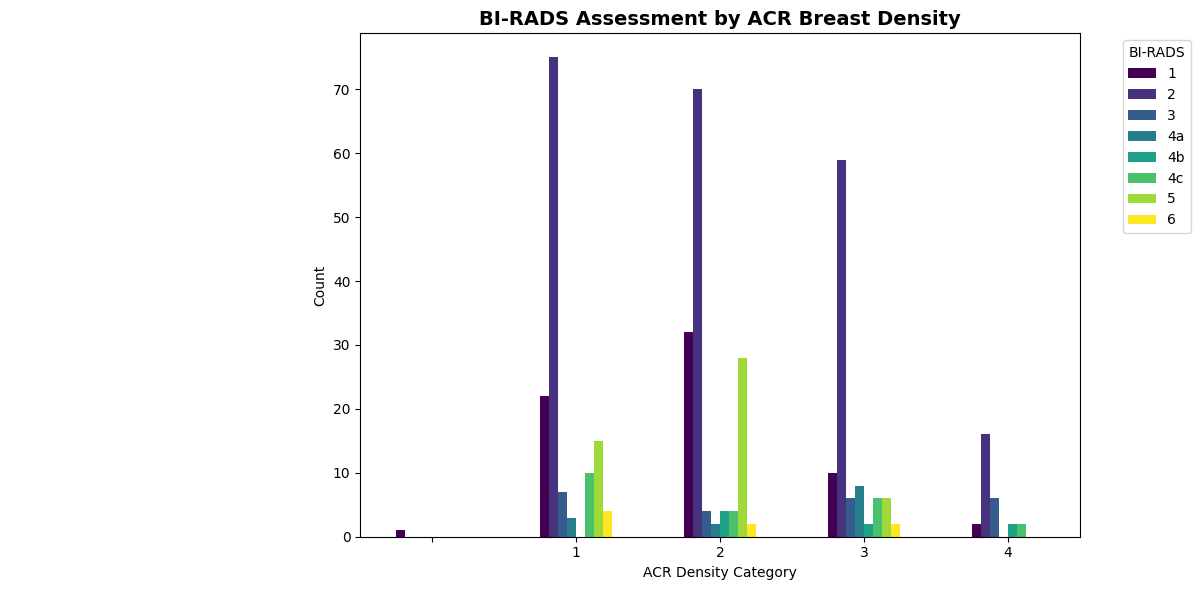

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Filter out empty ACR values
df_filtered = inbreast_df[inbreast_df['ACR'] != '']
birads_acr = pd.crosstab(df_filtered['ACR'], df_filtered['Bi-Rads'])
birads_acr.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('BI-RADS Assessment by ACR Breast Density', fontsize=14, fontweight='bold')
ax.set_xlabel('ACR Density Category')
ax.set_ylabel('Count')
ax.legend(title='BI-RADS', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Cross-Analysis: Pathology by View

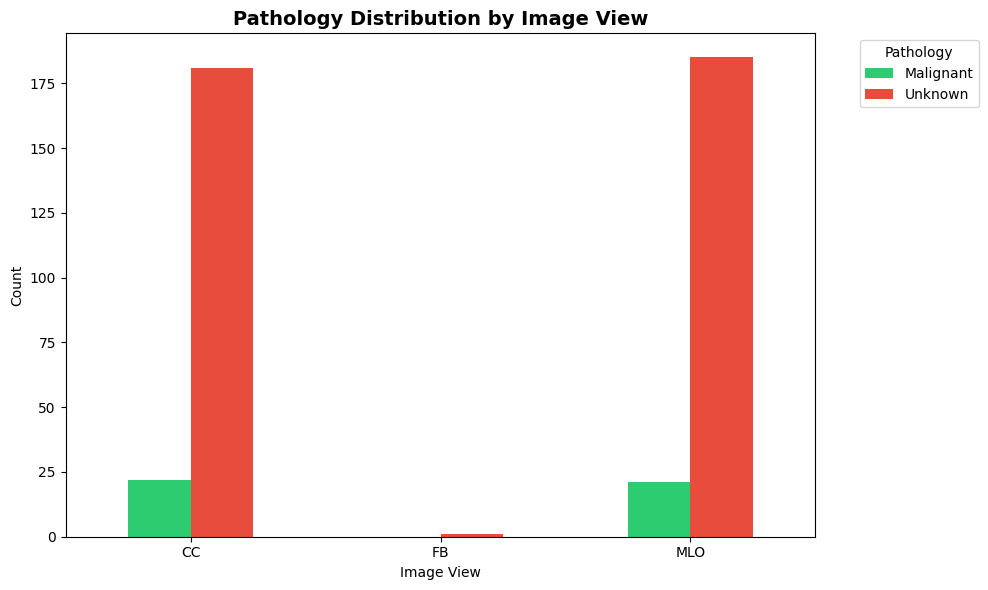

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

pathology_view = pd.crosstab(inbreast_df['View'], inbreast_df['pathology'])
pathology_view.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Pathology Distribution by Image View', fontsize=14, fontweight='bold')
ax.set_xlabel('Image View')
ax.set_ylabel('Count')
ax.legend(title='Pathology', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Sample image filename: 22678646


Patient ID           removed
Patient age          removed
Laterality                 L
View                      CC
Acquisition date      201001
File Name           22678646
ACR                        4
Bi-Rads                    3
pathology            Unknown
Name: 1, dtype: object

DICOM path: ../datasets/INbreast Release 1.0/AllDICOMs/22678646_61b13c59bcba149e_MG_L_CC_ANON.dcm
File exists: True


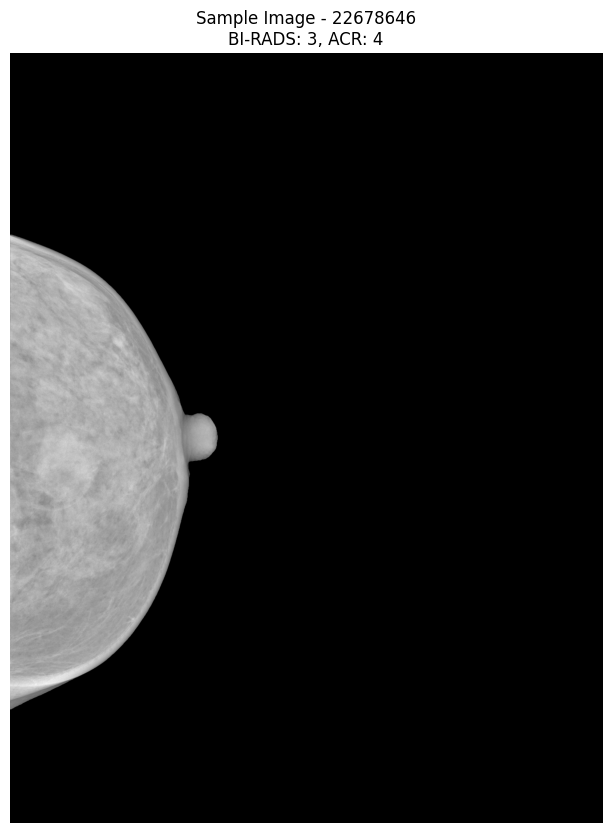

Image shape: (3328, 2560)
Pixel value range: [0, 2287]


22678646

ROI file: ../datasets/INbreast Release 1.0/AllROI/22678646.roi
ROI file exists: True


ROI Type: Mass
Number of points: 133

First 5 points:
  Point 0: (207.94, 1937.72)
  Point 1: (199.60, 1935.34)
  Point 2: (192.78, 1932.28)
  Point 3: (189.50, 1925.48)
  Point 4: (183.42, 1920.92)


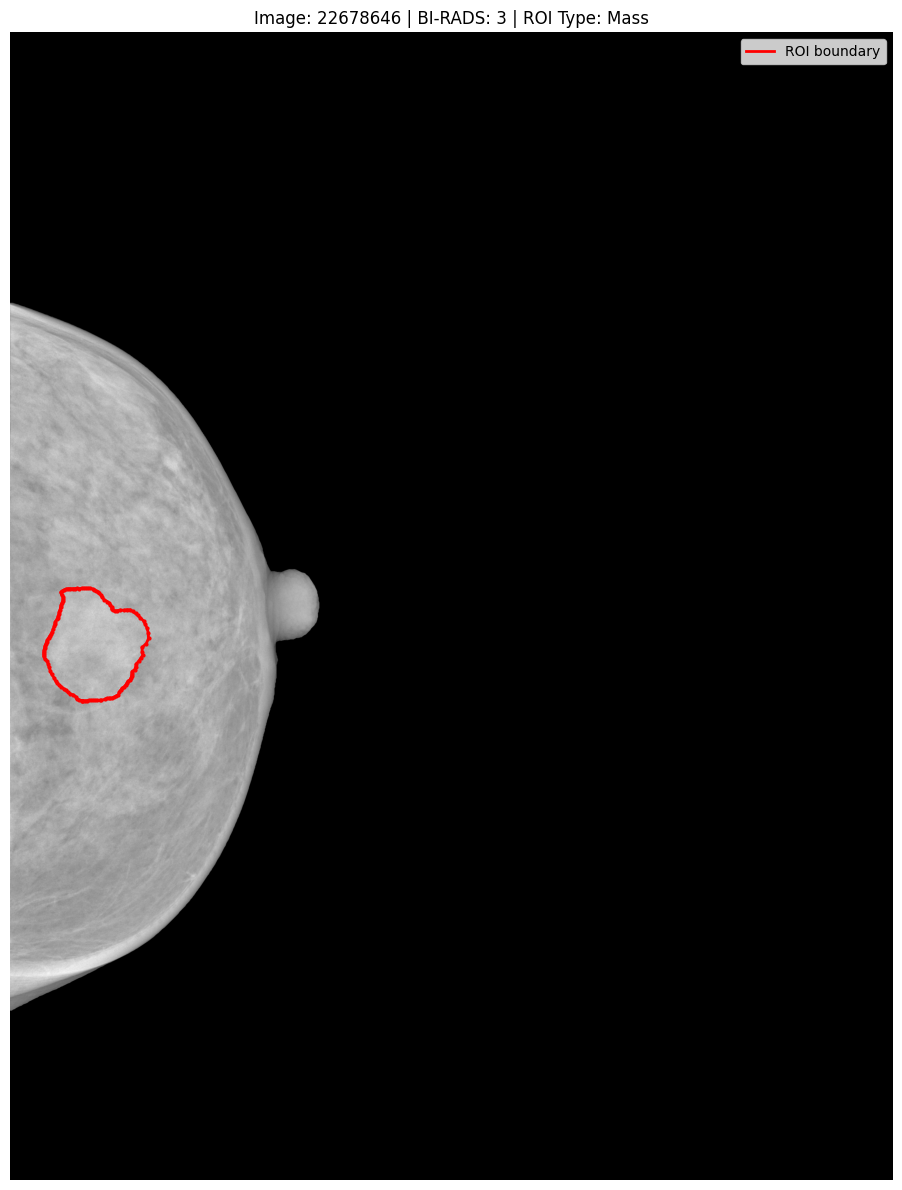

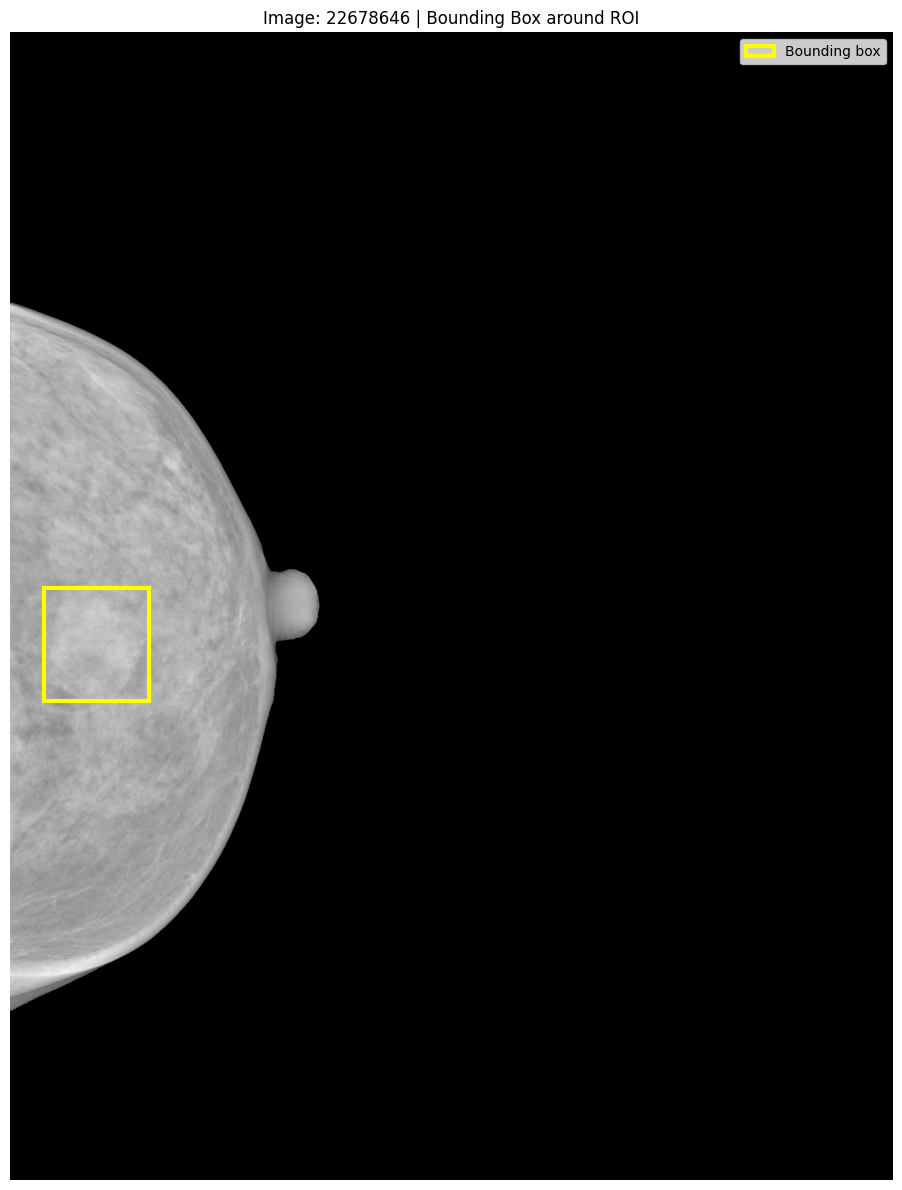

## Questions

How do I find images across patients?

